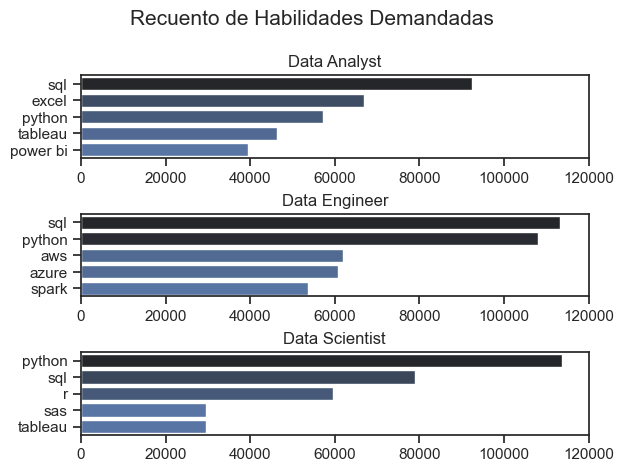

In [18]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
#df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

top_roles = df["job_title_short"].value_counts().head(3).index.tolist()

df = df[df["job_title_short"].isin(top_roles)]
df = df.explode("job_skills")
df_grouped = df.groupby("job_title_short")["job_skills"].value_counts().reset_index(name="skill_counts")


fig, ax = plt.subplots(len(top_roles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(top_roles):
    df_plot = df_grouped[df_grouped['job_title_short'] == job_title].head(5)[::-1]

    sns.barplot(data=df_plot, x='skill_counts', y='job_skills', ax=ax[i], hue='skill_counts', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 120000) 

fig.suptitle('Recuento de Habilidades Demandadas', fontsize=15)
fig.tight_layout(h_pad=0.5) 
plt.show()


